In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from numba import njit
from itertools import product
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import datetime
import pandas as pd
from tqdm import tqdm


import LLE_PR_activities_module as md
import FORCE_module as FC

import psutil



In [ ]:
# module functions:


@njit(fastmath=True)
def euler_rate_network_numba(W, tau, dt, t_steps, x0, I, return_full=True):
    """
    Euler integration of the rate network (numba-accelerated).

    Parameters:
        W           : ndarray (N x N), Weight matrix
        tau         : float, Time constant
        dt          : float, Integration step size
        t_steps     : int, Number of time steps to simulate
        x0          : ndarray (N,), Initial state
        I           : ndarray (t_steps x N) or (N,), Input array (constant or time dependent)
        return_full : bool
                      if True, return full trajectory (t_steps x N)
                      if False, return only the last state (N,)

    Returns:
        x           : ndarray, full trajectory or last state depending on `return_full`.
    """
    N = len(x0)
    if return_full:
        x = np.zeros((t_steps, N), dtype=x0.dtype)
        x[0] = x0
    else:
        x = np.copy(x0)

    X = np.copy(x0)

    for i in range(1, t_steps):
        # select input (time varying or constant)
        if I.ndim == 2:
            Ii = I[i - 1]
        else:
            Ii = I

        X = X + dt * md.rate_network_numba(X, W, Ii, tau)

        if return_full:
            x[i] = X

    return x if return_full else X


def lyapunov_exponent_numba_and_10th_activity(running_time, reset_steps, tau, perturbation, N, W, dt, X0):
    """

    Arguments:
        running_time : 1D array of timesteps
        reset_steps  : steps between resetting the X1/X2 distance back to `perturbation`
        tau          : time constant
        perturbation : initial/reset perturbation magnitude between X1 and X2
        N            : number of neurons
        W            : weight matrix (N x N)
        dt           : integration timestep
        X0           : initial state vector (1D, length N)

    Returns:
        (largest_lyapunov_exponent, distances, activity_X1, activity_X2)
    """
    steps = len(running_time)
    X1 = np.copy(X0)
    X2 = np.copy(X0 + perturbation / np.sqrt(N))

    distances = np.empty(steps, dtype=X0.dtype)
    distances[0] = np.linalg.norm(X2 - X1)

    activity_X1 = []
    activity_X2 = []

    # Save only every 10th neuron (0, 10, 20, ...)
    activity_X1.append(X1[::10])
    activity_X2.append(X2[::10])

    I = np.zeros(N)  # constant zero input
    for t in range(1, steps):
        X1 = X1 + dt * md.rate_network_numba(X1, W, I, tau)
        X2 = X2 + dt * md.rate_network_numba(X2, W, I, tau)

        activity_X1.append(X1[::10])
        activity_X2.append(X2[::10])

        dist_vec = X2 - X1
        dist_mag = np.linalg.norm(dist_vec)
        distances[t] = dist_mag
        if t % reset_steps == 0:
            unit_vec = dist_vec / dist_mag
            X2 = X1 + perturbation * unit_vec

    # Local slope estimate (manual least-squares -- same math as md.lyapunov_slopes)
    log_distances = np.log(distances)
    lyaps = []
    for i in range(0, steps - reset_steps, reset_steps):
        t_chunk = running_time[i:i + reset_steps]
        d_chunk = log_distances[i:i + reset_steps]
        x_mean = t_chunk.mean()
        y_mean = d_chunk.mean()
        num = ((t_chunk - x_mean) * (d_chunk - y_mean)).sum()
        den = ((t_chunk - x_mean) ** 2).sum()
        lyaps.append(num / den)

    distances = np.array(distances)
    activity_X1 = np.array(activity_X1)
    activity_X2 = np.array(activity_X2)

    return np.mean(np.array(lyaps)), distances, activity_X1, activity_X2


def lyapunov_exponent_numba_and_activity(running_time, reset_steps, tau, perturbation, N, W, dt, X0):
    """
    Like lyapunov_exponent_numba_and_10th_activity above, but records the
    FULL (all-neuron) activity at every single timestep rather than every
    10th neuron -- much more memory-hungry. Currently only referenced from 
    a commented-out line further down this notebook
    (kept here in case you switch back to it).
    """
    steps = len(running_time)
    X1 = np.copy(X0)
    X2 = np.copy(X0 + perturbation / np.sqrt(N))

    distances = np.empty(steps, dtype=X0.dtype)
    distances[0] = np.linalg.norm(X2 - X1)

    activity_X1 = [X1[0:1000:10]]
    activity_X2 = [X2]

    I = np.zeros(N)
    for t in range(1, steps):
        X1 = X1 + dt * md.rate_network_numba(X1, W, I, tau)
        X2 = X2 + dt * md.rate_network_numba(X2, W, I, tau)

        activity_X1.append(X1)
        activity_X2.append(X2)

        dist_vec = X2 - X1
        dist_mag = np.linalg.norm(dist_vec)
        distances[t] = dist_mag
        if t % reset_steps == 0:
            unit_vec = dist_vec / dist_mag
            X2 = X1 + perturbation * unit_vec

    log_distances = np.log(distances)
    lyaps = []
    for i in range(0, steps - reset_steps, reset_steps):
        t_chunk = running_time[i:i + reset_steps]
        d_chunk = log_distances[i:i + reset_steps]
        x_mean = t_chunk.mean()
        y_mean = d_chunk.mean()
        num = ((t_chunk - x_mean) * (d_chunk - y_mean)).sum()
        den = ((t_chunk - x_mean) ** 2).sum()
        lyaps.append(num / den)

    distances = np.array(distances)
    activity_X1 = np.array(activity_X1)
    activity_X2 = np.array(activity_X2)

    return np.mean(np.array(lyaps)), distances, activity_X1, activity_X2


def lyapunov_exponent_numba_and_tanh_activity(running_time, reset_steps, tau, perturbation, N, W, dt, X0):
    """
    Records tanh(X) (firing rate r, not the raw state x)
    at every timestep for both trajectories. 
    """
    steps = len(running_time)
    X1 = np.copy(X0)
    X2 = np.copy(X0 + perturbation / np.sqrt(N))

    R1 = np.tanh(X1)
    R2 = np.tanh(X2)

    distances = np.empty(steps, dtype=X0.dtype)
    distances[0] = np.linalg.norm(R2 - R1)

    activity_R1 = [R1]
    activity_R2 = [R2]

    I = np.zeros(N)
    for t in range(1, steps):
        X1 = X1 + dt * md.rate_network_numba(X1, W, I, tau)
        X2 = X2 + dt * md.rate_network_numba(X2, W, I, tau)

        R1 = np.tanh(X1)
        R2 = np.tanh(X2)
        activity_R1.append(R1)
        activity_R2.append(R2)

        dist_vec = R2 - R1
        dist_mag = np.linalg.norm(dist_vec)
        distances[t] = dist_mag
        if t % reset_steps == 0:
            unit_vec = dist_vec / dist_mag
            R2 = R1 + perturbation * unit_vec

    log_distances = np.log(distances)
    lyaps = []
    for i in range(0, steps - reset_steps, reset_steps):
        t_chunk = running_time[i:i + reset_steps]
        d_chunk = log_distances[i:i + reset_steps]
        x_mean = t_chunk.mean()
        y_mean = d_chunk.mean()
        num = ((t_chunk - x_mean) * (d_chunk - y_mean)).sum()
        den = ((t_chunk - x_mean) ** 2).sum()
        lyaps.append(num / den)

    distances = np.array(distances)
    activity_R1 = np.array(activity_R1)
    activity_R2 = np.array(activity_R2)

    return np.mean(np.array(lyaps)), distances, activity_R1, activity_R2


def distance_plots(running_time, save_dir, distances_sorted, seeds_sorted, HSMs_sorted):
    """
    Plot and save log-distance-vs-time for each (seed, HSM) pair.
    """
    for index, (seed, HSM) in enumerate(zip(seeds_sorted, HSMs_sorted)):
        plt.figure(figsize=(10, 5))
        plt.semilogy(running_time, distances_sorted[index, :])
        plt.xlabel("Time")
        plt.ylabel("log(distances between X2 and X1)")
        plt.title(f"{index}. Lyapunov divergence for heterogeneity HSM {HSM}, seed {seed}")
        plt.grid(True)

        filename = f"plot_{index}_HSM{HSM:.2f}_seed_{seed:.2f}.png"
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath)
        plt.close()  # close figure to save memory

    plt.show()


# Generating Local Data 

In [ ]:
# Small scratch/test run (N=10) exercising euler_rate_network_numba directly.

# Parameters
N = 10
tau = 10
dt = 0.1

p = 1

running_time = np.arange(0, 800 + dt, dt)
t_steps = len(running_time)

n_weight_seeds = np.array([9])
n_init_seeds = np.array([1])

HSM = 5
gain = 0

weights_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, n_weight_seeds))
initialisation_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, n_weight_seeds, n_init_seeds))

rng_weights = np.random.default_rng(weights_seq)
rng_initialisation = np.random.default_rng(initialisation_seq)

x0 = rng_initialisation.uniform(-1.0, 1.0, size=N)
W = md.compute_weight_matrix(p, N, HSM, gain, rng_weights)

I = np.zeros((len(running_time), N))

activity = euler_rate_network_numba(W, tau, dt, t_steps, x0, I, return_full=True)


In [ ]:
# Main sweep: for each (gain, weights_seed, HSM, init_seed) combination,
# build a weight matrix and compute its largest Lyapunov exponent plus
# sampled activity of the two diverging trajectories.

# Parameters
N = 1000
tau = 10
dt = 0.1

p = 1

running_time = np.arange(0, 800 + dt, dt)
interval = 200
reset_steps = int(interval / dt)
perturbation = 1e-8

n_weight_seeds = np.array([9])
n_init_seeds = np.array([0])

# Active sweep values (see commented alternatives below for other configs
# that have been tried)
HSMs = np.array([0, 1.5, 5])
gains = np.array([0.6, 5, 10])
# HSMs = np.array([0.2])
# HSMs = np.array([0, 0.5, 1, 2, 5])
# gains = np.array([0.1, 0.5, 1, 4.2, 10])
# gains = np.array([0.0, 1.0, 1.5, 2.0, 2.5, 5.0, 10.0])
# gains = np.array([0.0])
# HSMs = np.array([0.0, 0.2, 0.4, 1.0, 1.5, 2.6, 5])
# gains = np.arange(0, 1.2, 0.2)

tasks = list(product(gains, n_weight_seeds, HSMs, n_init_seeds))

# Local storage for results
local_LLEs = []
local_distances = []
local_activity_X1 = []
local_activity_X2 = []
local_Weights_Seeds = []
local_Initialisation_Seeds = []
local_HSMs = []
local_Gains = []

for gain, weights_seed, HSM, initialisation_seed in tqdm(tasks):

    # Independent, reproducible RNG streams for weights vs. initial state
    weights_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed))
    initialisation_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed, initialisation_seed))

    rng_weights = np.random.default_rng(weights_seq)
    rng_initialisation = np.random.default_rng(initialisation_seq)

    # Weight matrix
    W = md.compute_weight_matrix(p, N, HSM, gain, rng_weights)

    X0 = rng_initialisation.uniform(-1.0, 1.0, size=N)
    LLE, distances, activity_X1, activity_X2 = lyapunov_exponent_numba_and_10th_activity(
        running_time, reset_steps, tau, perturbation, N, W, dt, X0
    )
    # Alternative that records full (not every-10th) neuron activity instead:
    # LLE, distances, activity_X1, activity_X2 = lyapunov_exponent_numba_and_activity(
    #     running_time, reset_steps, tau, perturbation, N, W, dt, X0
    # )

    local_LLEs.append(LLE)
    local_distances.append(distances)
    local_activity_X1.append(activity_X1)
    local_activity_X2.append(activity_X2)

    # Track parameters alongside results for later identification
    local_Gains.append(gain)
    local_Weights_Seeds.append(weights_seed)
    local_Initialisation_Seeds.append(initialisation_seed)
    local_HSMs.append(HSM)

# Convert accumulators to arrays
local_LLEs = np.array(local_LLEs)
local_distances = np.array(local_distances)
local_activity_X1 = np.array(local_activity_X1)
local_activity_X2 = np.array(local_activity_X2)
local_Weights_Seeds = np.array(local_Weights_Seeds)
local_Initialisation_Seeds = np.array(local_Initialisation_Seeds)
local_HSMs = np.array(local_HSMs)
local_Gains = np.array(local_Gains)


In [38]:
local_activity_X1 = [x[::10].astype(np.float32) for x in tqdm(local_activity_X1)]
local_activity_X2 = [x[::10].astype(np.float32) for x in tqdm(local_activity_X2)]


100%|██████████| 72/72 [00:18<00:00,  3.90it/s]


In [39]:
local_LLEs = np.array(local_LLEs)
local_distances = np.array(local_distances)
local_activity_X1 = np.array(local_activity_X1)
local_activity_X2 = np.array(local_activity_X2)
local_Weights_Seeds = np.array(local_Weights_Seeds)
local_Initialisation_Seeds = np.array(local_Initialisation_Seeds)
local_HSMs = np.array(local_HSMs)
local_Gains = np.array(local_Gains)

In [46]:
mem = psutil.virtual_memory()
print(f"Total RAM: {mem.total / 1e9:.2f} GB")
print(f"Available RAM: {mem.available / 1e9:.2f} GB")

Total RAM: 16.94 GB
Available RAM: 6.78 GB


# Checking r=tanh(x) MLEs

In [49]:
local_LLEs *= 1000

In [ ]:
# Heatmap of MLE (LLE) across Gain x HSM, averaged over weight/init seeds.
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14    # x/y labels
plt.rcParams['xtick.labelsize'] = 12   # x ticks
plt.rcParams['ytick.labelsize'] = 12   # y ticks
plt.rcParams['legend.fontsize'] = 10   # legend text
plt.rcParams['figure.titlesize'] = 16  # suptitle (global title)
plt.rcParams['legend.title_fontsize'] = 14  # legend title

# Custom blue-white-red diverging colormap, centered at 0
dark_red = "#8B0000"
white = "white"
dark_green = "#013220"
dark_blue = "#00008B"

colors = [dark_blue, white, dark_red]  # Blue -> White -> Red
n_bins = 100
cmap_name = 'custom_seismic'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

# Put results into a DataFrame for easy grouping/pivoting
df = pd.DataFrame({
    'G': [t[0] for t in tasks],
    'W': [t[1] for t in tasks],
    'HSM': [t[2] for t in tasks],
    'I': [t[3] for t in tasks],
    'L': local_LLEs
})

# Average over W and I seeds for each (G, HSM) combination.
# (To ignore W and I entirely instead, comment the line below and use the
# commented alternative underneath it.)
df_mean = df.groupby(['G', 'W', 'I', 'HSM'], as_index=False)['L'].mean()
# df_mean = df.groupby(['G', 'HSM'], as_index=False)['L'].mean()

heatmap_data = df_mean.pivot_table(index='G', columns='HSM', values='L', aggfunc='mean')

vmax = np.abs(heatmap_data.values).max()
vmin = -vmax

# Center the colormap at 0 so positive/negative LLE are symmetric around white
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

plt.figure(figsize=(8, 6))
plt.pcolormesh(heatmap_data.columns, heatmap_data.index, heatmap_data.values,
               shading='auto', cmap=cm, norm=norm)
plt.colorbar(label='Maximal Lyapunov Exponent (MLE) ($s^{-1}$)')
plt.xlabel('Heterogeneity of Synaptic Mean (HSM)')
plt.ylabel('Gain')
plt.title('Heatmap of MLEs for r=tanh(x), I and W seed 0, 1000N')

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_ %H;%M;%S")

filename = f"MLE_Map_gain_HSM_tanh(x)_1000N_{timestamp}.png"
# NOTE: hardcoded, machine-specific path -- update if running on a different machine
filepath = os.path.join(
    r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\LLE\MLE map 3000N",
    filename
)
plt.savefig(filepath, dpi=300)

plt.show()


# LLE vs HSM, one line per (weight_seed, init_seed), one figure per gain.

In [ ]:
# LLE vs HSM, one line per (weight_seed, init_seed), one figure per gain.

plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14    # x/y labels
plt.rcParams['xtick.labelsize'] = 12   # x ticks
plt.rcParams['ytick.labelsize'] = 12   # y ticks
plt.rcParams['legend.fontsize'] = 10   # legend text
plt.rcParams['figure.titlesize'] = 16  # suptitle (global title)
plt.rcParams['legend.title_fontsize'] = 14  # legend title

n_weight_seeds = np.array([0])
n_init_seeds = np.array([0])
gains = np.array([0.0, 0.4, 1.0, 1.5, 2.0, 2.5, 4.0, 8.0, 10.0])
HSMs = np.array([0.0, 0.2, 0.4, 1.0, 1.4, 2.6, 3.0, 4.5])
# HSMs = np.array([0.2])
# HSMs = np.array([0, 0.5, 1, 2, 5])
# gains = np.array([0.1, 0.5, 1, 4.2, 10])
# gains = np.array([0.0])
# gains = np.arange(0, 1.2, 0.2)

tasks = list(product(gains, n_weight_seeds, HSMs, n_init_seeds))

unique_Gains = np.unique(gains)
print(unique_Gains)

unique_HSMs = np.unique(HSMs)
print(unique_HSMs)

# Colors for weight seeds
weights_seeds = np.unique(n_weight_seeds)
print(weights_seeds)

color_map = {ws: plt.cm.tab10(i % 10) for i, ws in enumerate(weights_seeds)}

# Linestyles for initialisation seeds
init_seeds_unique = np.unique(n_init_seeds)
print(init_seeds_unique)

linestyle_tuple = [
    ('solid', 'solid'),
    ('dotted', 'dotted'),
    ('dashed', 'dashed'),
    ('dashdot', 'dashdot'),
    ('loosely dotted', (0, (1, 10))),
    ('densely dotted', (0, (1, 1))),
    ('loosely dashed', (0, (5, 10))),
    ('densely dashed', (0, (5, 1))),
    ('dashdotted', (0, (3, 5, 1, 5))),
    ('densely dashdotted', (0, (3, 1, 1, 1)))
]
linestyle_map = {is_: linestyle_tuple[i % len(linestyle_tuple)][1]
                 for i, is_ in enumerate(init_seeds_unique)}

# Loop over all combinations of seeds and gains
for i, gain in enumerate(unique_Gains):

    plt.figure(figsize=(10, 5))
    for w_seed in weights_seeds:
        for i_seed in init_seeds_unique:
            # Find indices matching this combination
            mask = ((local_Weights_Seeds == w_seed)
                     & (local_Initialisation_Seeds == i_seed)
                     & (local_Gains == gain))
            if not np.any(mask):
                continue

            lles = np.array(local_LLEs)[mask]

            # Sanity check: must align with unique_HSMs length
            if len(lles) != len(unique_HSMs):
                print(f"Skipping w={w_seed}, i={i_seed}, wrong length {len(lles)}")
                continue

            plt.plot(unique_HSMs[:-1], lles[:-1],
                     color=color_map[w_seed],
                     linestyle=linestyle_map[i_seed],
                     marker='o')
            # label=f"W={w_seed}, I={i_seed}") # put this back to see all init seeds in the legend too

    # Legend handles only for weight seeds (colours)
    handles = [plt.Line2D([0], [0], color=color_map[w], lw=3, label=f"W={w}") for w in weights_seeds]

    plt.xlabel("HSM")
    plt.ylabel("MLE")
    plt.ylim(-130, 130)
    plt.title(f"Maximal Lyapunov Exponent for 1000 N RNN and gain of {gain:.1f}")
    plt.grid(True)
    plt.legend(handles=handles, title="Weight Seeds*", bbox_to_anchor=(1.05, 1), fontsize=16)
    plt.tight_layout()

    filename = f"MLE Figure {i} for gain {gain:.1f}.png"
    # NOTE: hardcoded, machine-specific path
    filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\LLE\MLE across HSM and W and I seeds for different gains",
        filename
    )
    plt.subplots_adjust(right=0.8)
    plt.savefig(filepath, dpi=300)
    plt.show()


# Distance plots

In [ ]:
# Distance-over-time plot (log scale) for every (gain, HSM, weight_seed, init_seed)
# combination present in the sweep results from the cell above.
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 46
plt.rcParams['xtick.labelsize'] = 40
plt.rcParams['ytick.labelsize'] = 40
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

# tick size:
plt.rcParams['xtick.major.size'] = 8    # length of major ticks
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2   # width of major ticks
plt.rcParams['ytick.major.width'] = 2

# Parameters
N = 1000
tau = 10
dt = 0.1
p = 1
weights_seed = np.array([9])
n_init_seeds = np.array([0])
HSMs = np.array([0, 1.5, 5])
gains = np.array([0, 5, 10])
running_time = np.arange(0, 800 + dt, dt)

unique_Gains = np.unique(local_Gains)
print(unique_Gains)

unique_HSMs = np.unique(local_HSMs)
print(unique_HSMs)

unique_Weights_Seeds = np.unique(local_Weights_Seeds)
print(unique_Weights_Seeds)

unique_Init_Seeds = np.unique(local_Initialisation_Seeds)
print(unique_Init_Seeds)

neuron_colors_X2 = ['red', 'green', 'blue']
neuron_indices_X = [0, 1, 2, 3, 4, 995, 996, 997, 998, 999]
neuron_indices_X2 = [0, 499, 999]

for i, (gi, wi, HSMi, Ii) in enumerate(np.ndindex(len(unique_Gains), len(unique_Weights_Seeds), len(unique_HSMs), len(unique_Init_Seeds)), start=1):

    gain = unique_Gains[gi]
    HSM = unique_HSMs[HSMi]
    w_seed = unique_Weights_Seeds[wi]
    i_seed = unique_Init_Seeds[Ii]

    # Find this parameter combination's distances
    Mask = (local_Initialisation_Seeds == i_seed) & (local_Weights_Seeds == w_seed) & (local_HSMs == HSM) & (local_Gains == gain)
    distances_masked = local_distances[Mask]

    plt.figure(figsize=(14, 10))
    plt.plot(running_time[0:2000], distances_masked[0, 0:2000], '-', linewidth=3, color='tab:blue')

    plt.yscale('log')

    plt.xlabel('Time (ms)')
    plt.ylabel('||x(t) - x(t)+δ(t)||')
    plt.ylim([0.0000000001, 100])

    # plt.title(f"Distance evolution for gain={gain:.1f}, HSM={HSM:.1f}")
    plt.grid(True, alpha=0.3)

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    distance_filename = f"distance_gain{gain:.1f}_HSM{HSM:.1f}_Wseed{w_seed}_Iseed{i_seed}_per{perturbation}_time{timestamp}.png"
    # NOTE: hardcoded, machine-specific path
    distance_filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\Activity RNN\Distance plots for final presentation",
        distance_filename
    )

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    plt.savefig(distance_filepath, dpi=300, bbox_inches='tight')
    plt.show()



# Eigenvalue Spectra

In [ ]:
# Eigenvalue spectrum of connection_matrix_fast-built matrices.

plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 46
plt.rcParams['xtick.labelsize'] = 40
plt.rcParams['ytick.labelsize'] = 40
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

# tick size:
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

# Parameters
N = 1000
tau = 10
dt = 0.1
p = 1

weights_seed = np.array([9])
n_init_seeds = np.array([1])
# HSMs = np.array([0.2])
# gains = np.array([0.0, 0.2, 1.0, 5, 10])
# HSMs = np.array([0.0, 0.2, 1.0, 2.5, 5])

HSMs = np.array([0, 2.5, 5])
gains = np.array([0, 5, 10])

for gain in gains:
    for HSM in HSMs:

        weights_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed))
        # initialisation_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed, initialisation_seed))

        rng_weights = np.random.default_rng(weights_seq)
        # rng_initialisation = np.random.default_rng(initialisation_seq)

        W = connection_matrix_fast(p, N, HSM, gain, rng_weights)

        eigs = np.linalg.eigvals(W)
        eigs, eigvecs = np.linalg.eig(W)

        idx = np.argmax(np.abs(np.imag(eigs)))
        v = eigvecs[:, idx]

        top = np.argsort(np.abs(v))[::-1][:10]

        print("Eigenvalue:", eigs[idx])
        print("Top contributing neurons:", top)

        # get eigenvalue with maximal real part
        argmaxeig = np.argmax(np.real(eigs))
        maxeig = eigs[argmaxeig]

        plt.plot(np.real(eigs), np.imag(eigs), '.')
        plt.plot(np.real(maxeig), np.imag(maxeig), 'o', color='red')
        plt.plot(np.real(maxeig), -np.imag(maxeig), 'o', color='red')

        # draw expected eig border
        thetas = np.linspace(0, 2 * np.pi, 50)
        plt.plot(gain * np.cos(thetas), gain * np.sin(thetas), ':', color='gray')

        plt.vlines(x=1, ymin=-gain, ymax=gain, ls='--', color='black', alpha=0.8)

        plt.xlabel('Re($\\lambda$)')
        plt.ylabel('Im($\\lambda$)')

        plt.xlim([-11, 11])
        plt.ylim([-11, 11])

        plt.title(f"gain{gain:.1f}_HSM{HSM:.1f}")

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

        Rsquared_test_filename = f"gain{gain:.1f}_HSM{HSM:.1f}_time{timestamp}.png"
        # NOTE: hardcoded, machine-specific path
        Rsquared_test_filepath = os.path.join(
            r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\Activity RNN\Eigenvalue spectrum of untrained network",
            Rsquared_test_filename
        )

        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(2)

        plt.savefig(Rsquared_test_filepath, dpi=300, bbox_inches='tight')
        plt.show()


In [ ]:
# Eigenvalue spectrum of weight_matrix_fast-built matrices, with max-real
# and max-imaginary eigenvalues highlighted.
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 56
plt.rcParams['xtick.labelsize'] = 50
plt.rcParams['ytick.labelsize'] = 50
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

# tick size:
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

# Parameters
N = 1000
tau = 10
dt = 0.1
p = 1

weights_seed = np.array([9])
n_init_seeds = np.array([1])

# HSMs = np.array([0, 2.5, 5])
# gains = np.array([0, 5, 10])

HSMs = np.array([0, 1.5, 2.5, 5])
gains = np.array([0.6, 1, 5, 6, 10])

# HSMs = np.arange(0, 5.1, 0.2)
# gains = np.arange(0, 10.1, 0.2)

for gain in gains:
    for HSM in HSMs:

        plt.figure(figsize=(10, 10))

        weights_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed))
        rng_weights = np.random.default_rng(weights_seq)

        W = md.compute_weight_matrix(p, N, HSM, gain, rng_weights)
        eigs, eigvecs = np.linalg.eig(W)

        # Eigenvalue with maximal imaginary part
        idx_max_imag = np.argmax(np.abs(np.imag(eigs)))
        max_imag_eig = eigs[idx_max_imag]

        # Eigenvalue with maximal real part
        idx_max_real = np.argmax(np.real(eigs))
        max_real_eig = eigs[idx_max_real]

        # Eigenvalue with minimal real part
        idx_min_real = np.argmin(np.real(eigs))
        min_real_eig = eigs[idx_min_real]

        # Top contributing neurons for the max-imaginary eigenvalue
        v = eigvecs[:, idx_max_imag]
        top = np.argsort(np.abs(v))[::-1][:10]

        print(f"Max Imaginary Eigenvalue: {max_imag_eig}")
        print(f"Max Real Eigenvalue: {max_real_eig}")
        print(f"Min Real Eigenvalue: {min_real_eig}")
        print("Top contributing neurons:", top)

        plt.plot(np.real(eigs), np.imag(eigs), '.', markersize=16, label='All eigenvalues')

        marker_size = 20
        plt.plot(np.real(max_real_eig), np.imag(max_real_eig), 'o', color='red', markersize=marker_size,
                 label=f'Max Re: {np.real(max_real_eig):.2f} + {np.imag(max_real_eig):.2f}i')

        # Robust max-imag plotting: clip only for display, keep the true
        # value in the printed label
        ylim_low, ylim_high = -12, 12

        true_im = np.imag(max_imag_eig)
        true_re = np.real(max_imag_eig)

        plot_im_pos = np.clip(true_im, ylim_low, ylim_high)
        plot_im_neg = np.clip(-true_im, ylim_low, ylim_high)

        clipped = (true_im > ylim_high) or (true_im < ylim_low)

        plt.plot(
            true_re, plot_im_pos, '^', color='green', markersize=marker_size,
            clip_on=False, label=f'Max Im: {true_re:.2f} + {true_im:.2f}i'
        )
        plt.plot(
            true_re, plot_im_neg, 'v', color='green', markersize=marker_size,
            clip_on=False
        )

        # Draw expected eigenvalue border (circle of radius = gain)
        thetas = np.linspace(0, 2 * np.pi, 50)
        plt.plot(gain * np.cos(thetas), gain * np.sin(thetas), ':', color='gray',
                 label='Expected border')

        plt.vlines(x=1, ymin=-32, ymax=32, ls='--', color='black', alpha=0.8,
                   label='Re=1')

        plt.xlabel('Re($\\lambda$)')
        plt.ylabel('Im($\\lambda$)')
        plt.xlim([-12, 12])
        plt.ylim([ylim_low, ylim_high])

        plt.legend(loc='best', bbox_to_anchor=(2.20, 1), fontsize=40)
        # plt.title(f"gain{gain:.1f}_HSM{HSM:.1f}", pad=10)

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

        Rsquared_test_filename = f"gain{gain:.1f}_HSM{HSM:.1f}_time{timestamp}.png"
        # NOTE: hardcoded, machine-specific path
        Rsquared_test_filepath = os.path.join(
            r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\Activity RNN\Eigenvalue spectrum of untrained network",
            Rsquared_test_filename
        )

        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_linewidth(2)

        plt.savefig(Rsquared_test_filepath, dpi=300, bbox_inches='tight')
        plt.show()


# Eigenvalues, Activity, Distribution Combined Plots

In [ ]:
# Combined figure per (gain, HSM, weight_seed, init_seed): weight
# distribution, eigenvalue spectrum, and activity traces.
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 46
plt.rcParams['xtick.labelsize'] = 40
plt.rcParams['ytick.labelsize'] = 40
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

# tick size:
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

p = 1
N = 1000

plot_time = np.linspace(0, 3000.1, 30001)
plot_time_short = np.linspace(25000, 30000, 5000)

unique_Gains = np.unique(local_Gains)
print(unique_Gains)

unique_HSMs = np.unique(local_HSMs)
print(unique_HSMs)

unique_Weights_Seeds = np.unique(local_Weights_Seeds)
print(unique_Weights_Seeds)

unique_Init_Seeds = np.unique(local_Initialisation_Seeds)
print(unique_Init_Seeds)

neuron_colors_X2 = ['red', 'green', 'blue']
neuron_indices_X = [0, 1, 2, 3, 4, 995, 996, 997, 998, 999]
neuron_indices_X2 = [0, 499, 999]

for i, (gi, wi, HSMi, Ii) in enumerate(np.ndindex(len(unique_Gains), len(unique_Weights_Seeds), len(unique_HSMs), len(unique_Init_Seeds)), start=1):

    gain = unique_Gains[gi]
    HSM = unique_HSMs[HSMi]
    w_seed = unique_Weights_Seeds[wi]
    i_seed = unique_Init_Seeds[Ii]

    Mask = (local_Initialisation_Seeds == i_seed) & (local_Weights_Seeds == w_seed) & (local_HSMs == HSM) & (local_Gains == gain)

    X1_masked = local_activity_X1[Mask]
    X2_masked = local_activity_X2[Mask]

    fig, axes = plt.subplots(3, 1, figsize=(12, 18))

    # ---- Weight distribution ----
    weights_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, w_seed))
    rng_weights = np.random.default_rng(weights_seq)
    W = md.compute_weight_matrix(p, N, HSM, gain, rng_weights)

    axes[0].hist(W.ravel(), bins=1000, alpha=0.5, edgecolor="k",
                 label=f"HSM:{HSM}, g:{gain}")
    axes[0].set_xlabel('Frequency')
    axes[0].set_ylabel('Weight Value')
    # axes[0].legend(title="Distribution parameters", bbox_to_anchor=(1.4, 1), fontsize=20)

    # ---- Eigenvalue spectrum ----
    eigs = np.linalg.eigvals(W)
    argmaxeig = np.argmax(np.real(eigs))
    maxeig = eigs[argmaxeig]

    axes[1].plot(np.real(eigs), np.imag(eigs), '.', alpha=0.6)
    axes[1].plot(np.real(maxeig), np.imag(maxeig), 'o', color='red')
    axes[1].plot(np.real(maxeig), -np.imag(maxeig), 'o', color='red')

    thetas = np.linspace(0, 2 * np.pi, 200)
    axes[1].plot(gain * np.cos(thetas), gain * np.sin(thetas), ':', color='gray')
    axes[1].vlines(x=1, ymin=-gain, ymax=gain, linestyles='--', color='black', alpha=0.8)

    axes[1].set_xlabel('Re($\\lambda$)')
    axes[1].set_ylabel('Im($\\lambda$)')
    # axes[1].set_title(f"gain {gain:.1f}  HSM {HSM:.1f}")
    # axes[1].set_aspect('equal', adjustable='box')

    # ---- Activity traces ----
    for j, idx in enumerate(neuron_indices_X2):
        axes[2].plot(plot_time[:200], X1_masked[0, :200, idx],
                     color=neuron_colors_X2[j], lw=3, label=f'x(t) n_{idx+1}')

    for j, idx in enumerate(neuron_indices_X2):
        axes[2].plot(plot_time[:200], X2_masked[0, :200, idx],
                     color=neuron_colors_X2[j], lw=3, linestyle='--',
                     label=f'x(t)+δ(t) n_{idx+1}')

    axes[2].set_xlabel("time (ms)")
    axes[2].set_ylabel("Activity (A.U.)")
    # axes[2].set_title(f"HSG {gain:.1f}, HSM {HSM:.1f}")
    axes[2].legend(title="Neuron #:", bbox_to_anchor=(1.05, 1), fontsize=20)

    filename = f"Figure {i} distribution, eigenvalue, activity for gain {gain:.1f}, HSM {HSM:.1f}, W seed {w_seed}, and I seed {i_seed}.png"
    # NOTE: hardcoded, machine-specific path
    filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\Activity RNN\distribution, eigenvalue, MLE activity",
        filename
    )
    # plt.subplots_adjust(right=0.8)  # leaving space for legend
    # plt.savefig(filepath, dpi=300)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


# Activity plots and MLE cases per gain

## Different Activity Plots with Sensitivity of Initial Perturbation and Weight Seed

In [ ]:
# Activity traces (a handful of neurons) per (gain, HSM, weight_seed), zoomed
# into a short time window.
plt.rcParams['axes.titlesize'] = 30
plt.rcParams['axes.labelsize'] = 46
plt.rcParams['xtick.labelsize'] = 40
plt.rcParams['ytick.labelsize'] = 40
plt.rcParams['legend.fontsize'] = 36
plt.rcParams['figure.titlesize'] = 30
plt.rcParams['legend.title_fontsize'] = 30

# tick size:
plt.rcParams['xtick.major.size'] = 8
plt.rcParams['ytick.major.size'] = 8
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2

plot_time = np.linspace(0, 3000.1, 30001)
plot_time_short = np.linspace(25000, 30000, 5000)

unique_Gains = np.unique(local_Gains)
print(unique_Gains)

unique_HSMs = np.unique(local_HSMs)
print(unique_HSMs)

unique_Weights_Seeds = np.unique(local_Weights_Seeds)
print(unique_Weights_Seeds)

neuron_indices_X2 = [0, 20, 40, 60, 80, 99]
neuron_colors_X2 = ['green', 'blue', 'red', 'purple', 'orange', 'gray']
cmap = plt.cm.turbo
# neuron_colors_X2 = cmap(np.linspace(0, 1, len(neuron_indices_X2)))  # alt: colormap-based colors instead of the fixed list above

for i, (gi, wi, HSMi) in enumerate(np.ndindex(len(unique_Gains), len(unique_Weights_Seeds), len(unique_HSMs)), start=1):

    gain = unique_Gains[gi]
    HSM = unique_HSMs[HSMi]
    w_seed = unique_Weights_Seeds[wi]

    Mask = (local_Weights_Seeds == w_seed) & (local_HSMs == HSM) & (local_Gains == gain)

    X1_masked = local_activity_X1[Mask]
    X2_masked = local_activity_X2[Mask]

    plt.figure(figsize=(14, 12))

    # Only X1's traces are plotted here; see the commented block below for
    # how to add X2's traces (dashed) on top if you want the divergence visible.
    for j, idx in enumerate(neuron_indices_X2):
        plt.plot(plot_time[0:8000], X1_masked[0, 0:8000, idx],
                 color=neuron_colors_X2[j], lw=4.5,
                 label=f'x(t) n_{idx+1}', markersize=1)

    # for j, idx in enumerate(neuron_indices_X2):
    #     plt.plot(plot_time[0:8000], X2_masked[0, 0:8000, idx],
    #              color=neuron_colors_X2[j], lw=2.5, linestyle='--',
    #              label=f'x(t)+$\\delta$(t) n_{idx+1}', markersize=1)

    plt.xlabel("time (ms)")
    plt.ylabel("Activity (A.U.)")
    plt.ylim([-50, 50])
    plt.xlim([100, 200])

    # plt.title(f" HSG {gain:.1f}, HSM {HSM:.1f}, W seed {w_seed}")
    plt.grid(False)
    # plt.legend(title="Neuron #", bbox_to_anchor=(1.05, 1), fontsize=20)
    plt.tight_layout()

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"MLE Figure {i}  gain {gain:.1f}, HSM {HSM:.1f}, and W seed {w_seed}, time{timestamp}, Neurons=first and last and middle.png"
    # NOTE: hardcoded, machine-specific path -- change depending on 10% connectivity or not
    filepath = os.path.join(
        r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\Activity RNN\Activity for thesis",
        filename
    )

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    plt.savefig(filepath, dpi=300)
    plt.show()


## Self Connections and Sparsity in Weight Matrix

Pass 1: simulating all conditions...
  gain=0.5, MSH=0.0  →  y-limits: [-0.9217, 1.0048]
  gain=1.5, MSH=1.0  →  y-limits: [-37.0386, 27.8147]
  gain=6.0, MSH=5.0  →  y-limits: [-182.6315, 157.3177]
Pass 2: plotting and saving...
  Saved → p=0.2 with self connections gain 0.5, MSH 0.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


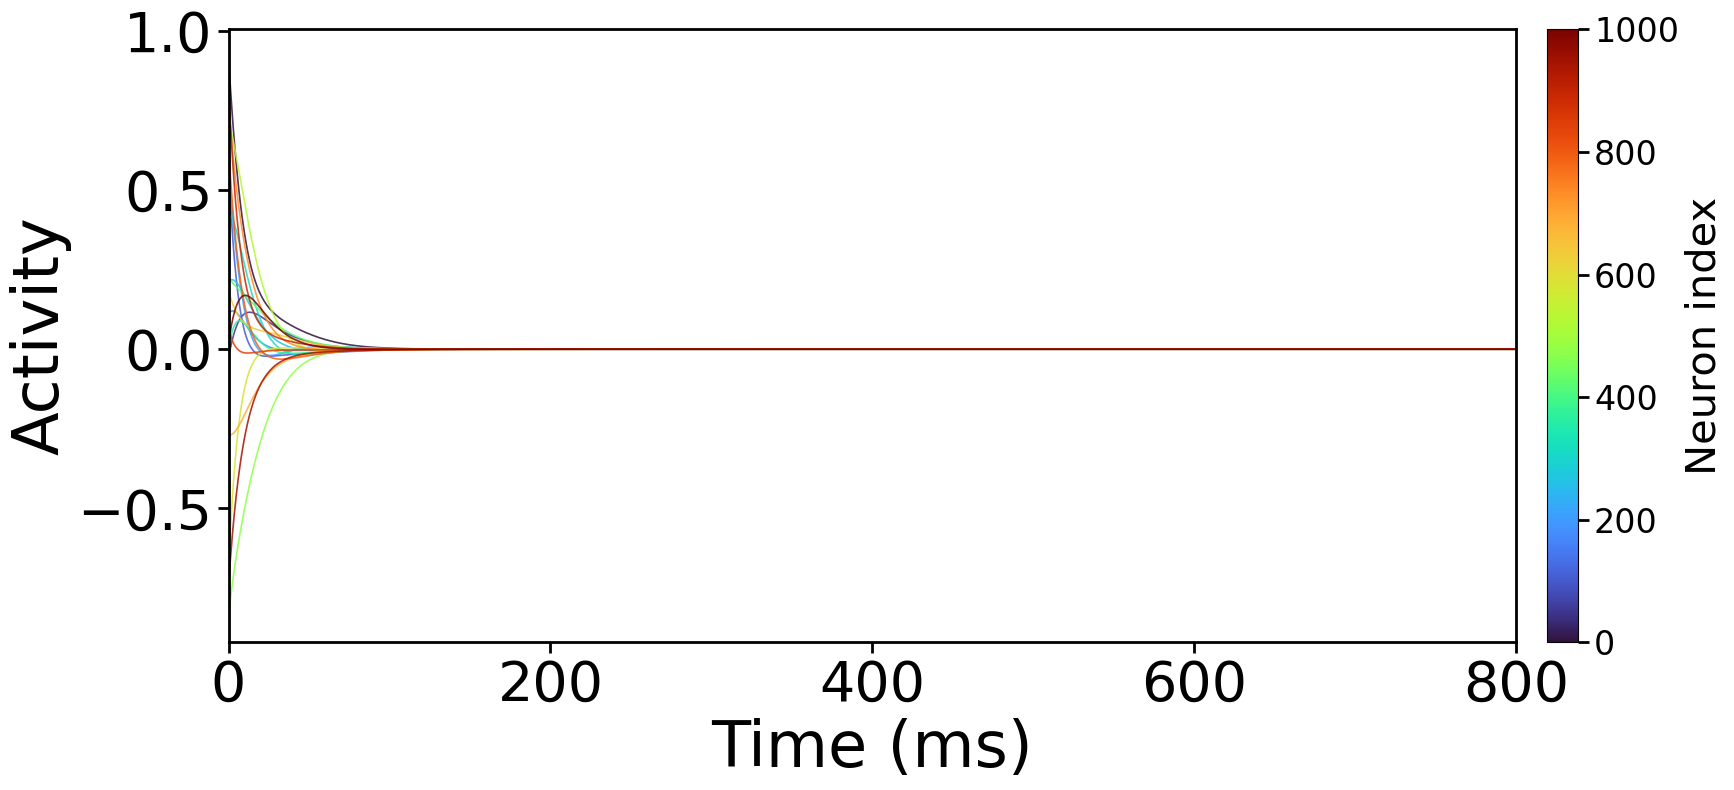

  Saved → p=0.2 with self connections gain 1.5, MSH 1.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


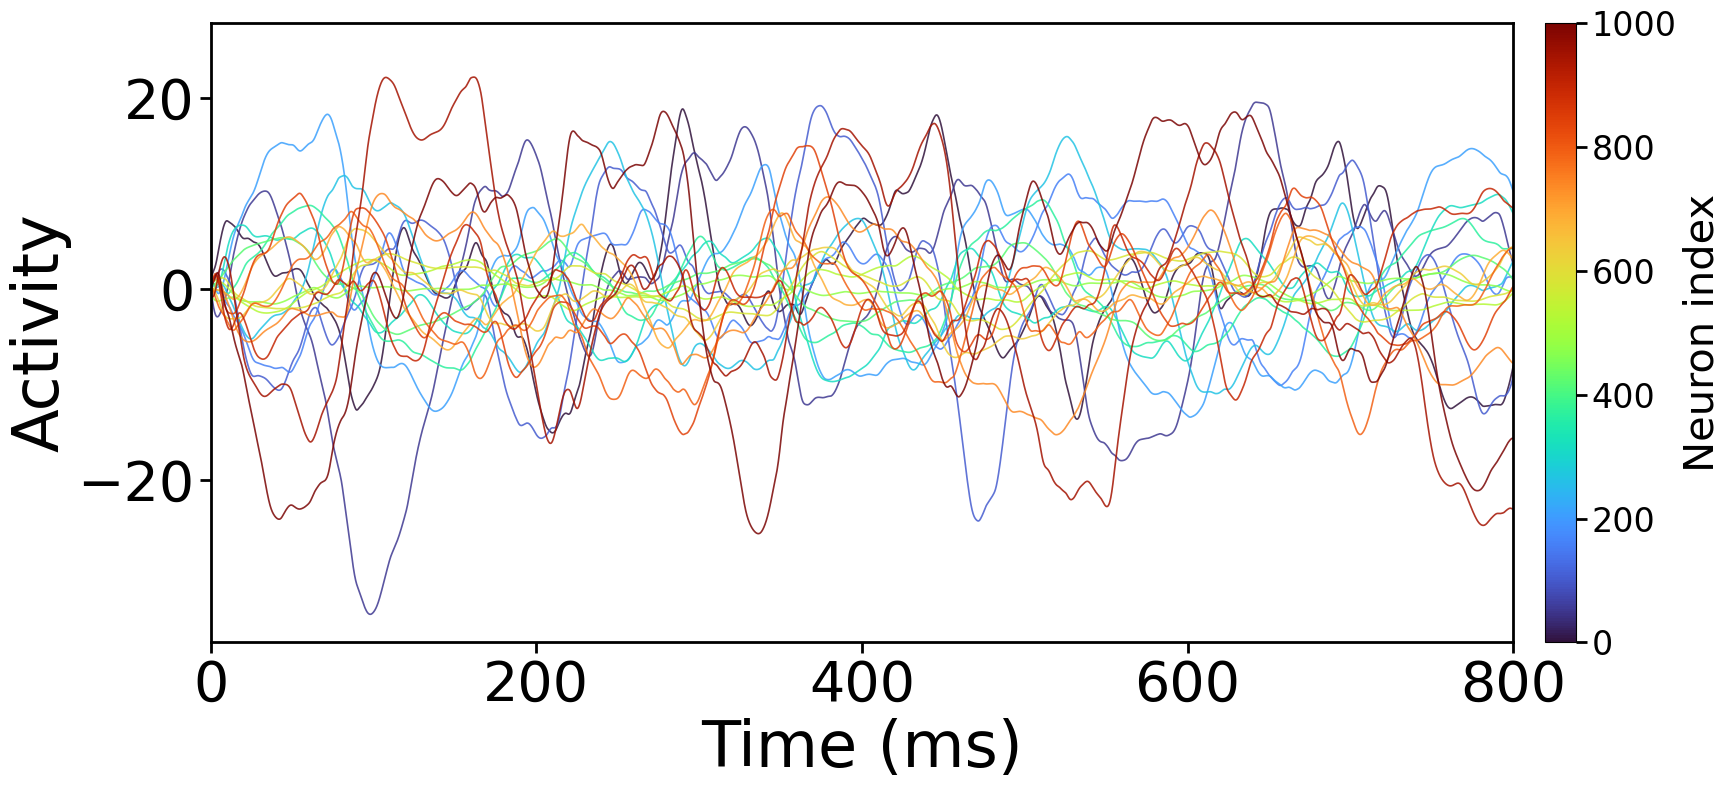

  Saved → p=0.2 with self connections gain 6.0, MSH 5.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


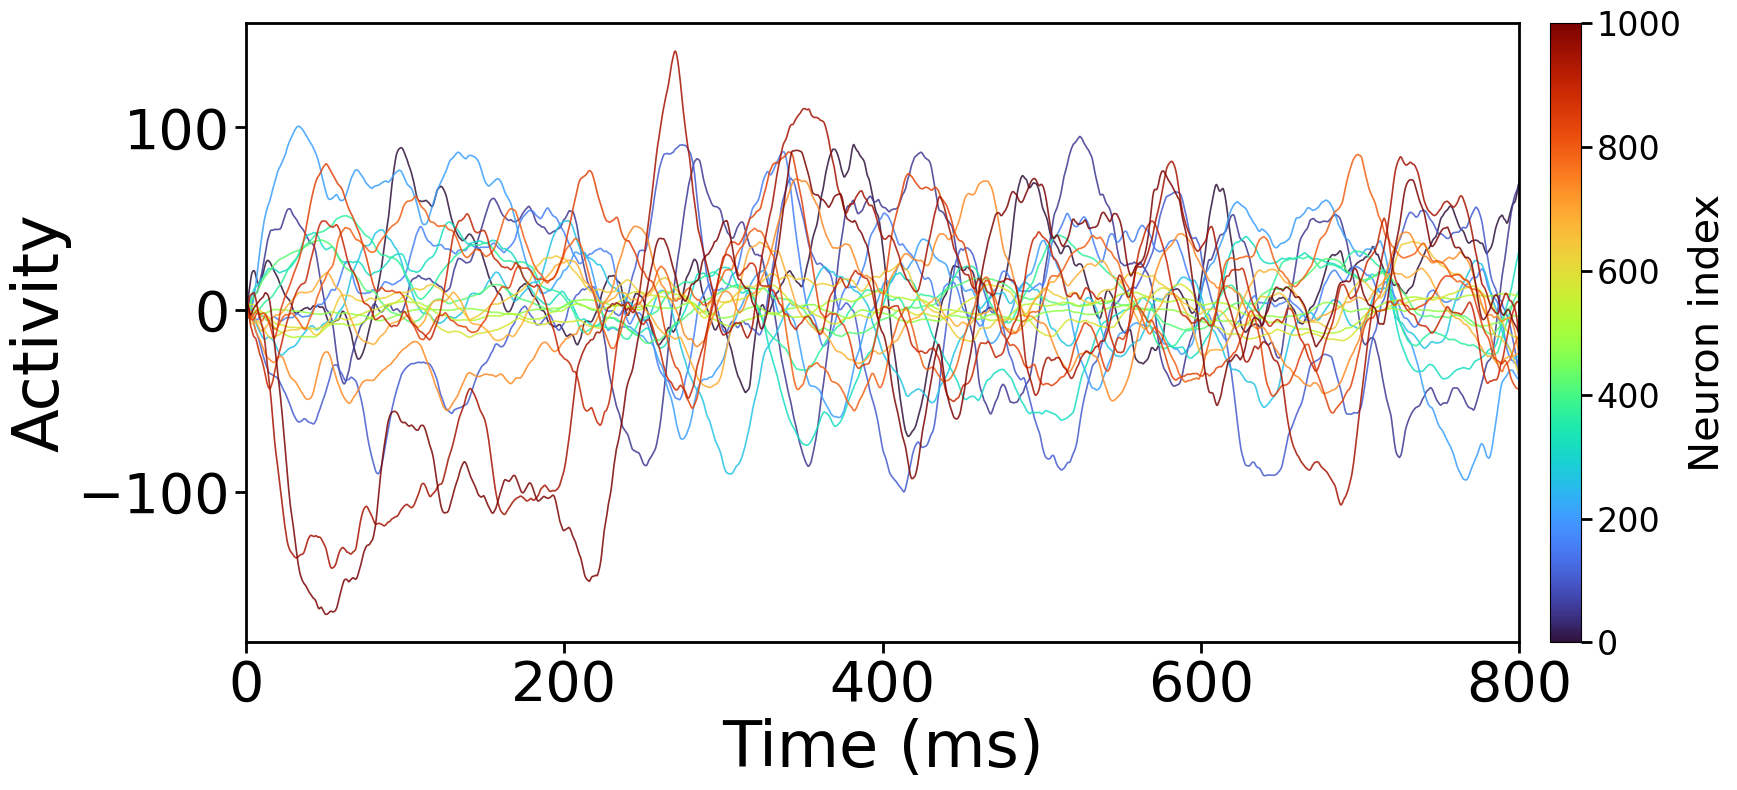

  Saved → p=0.2 without self connections gain 0.5, MSH 0.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


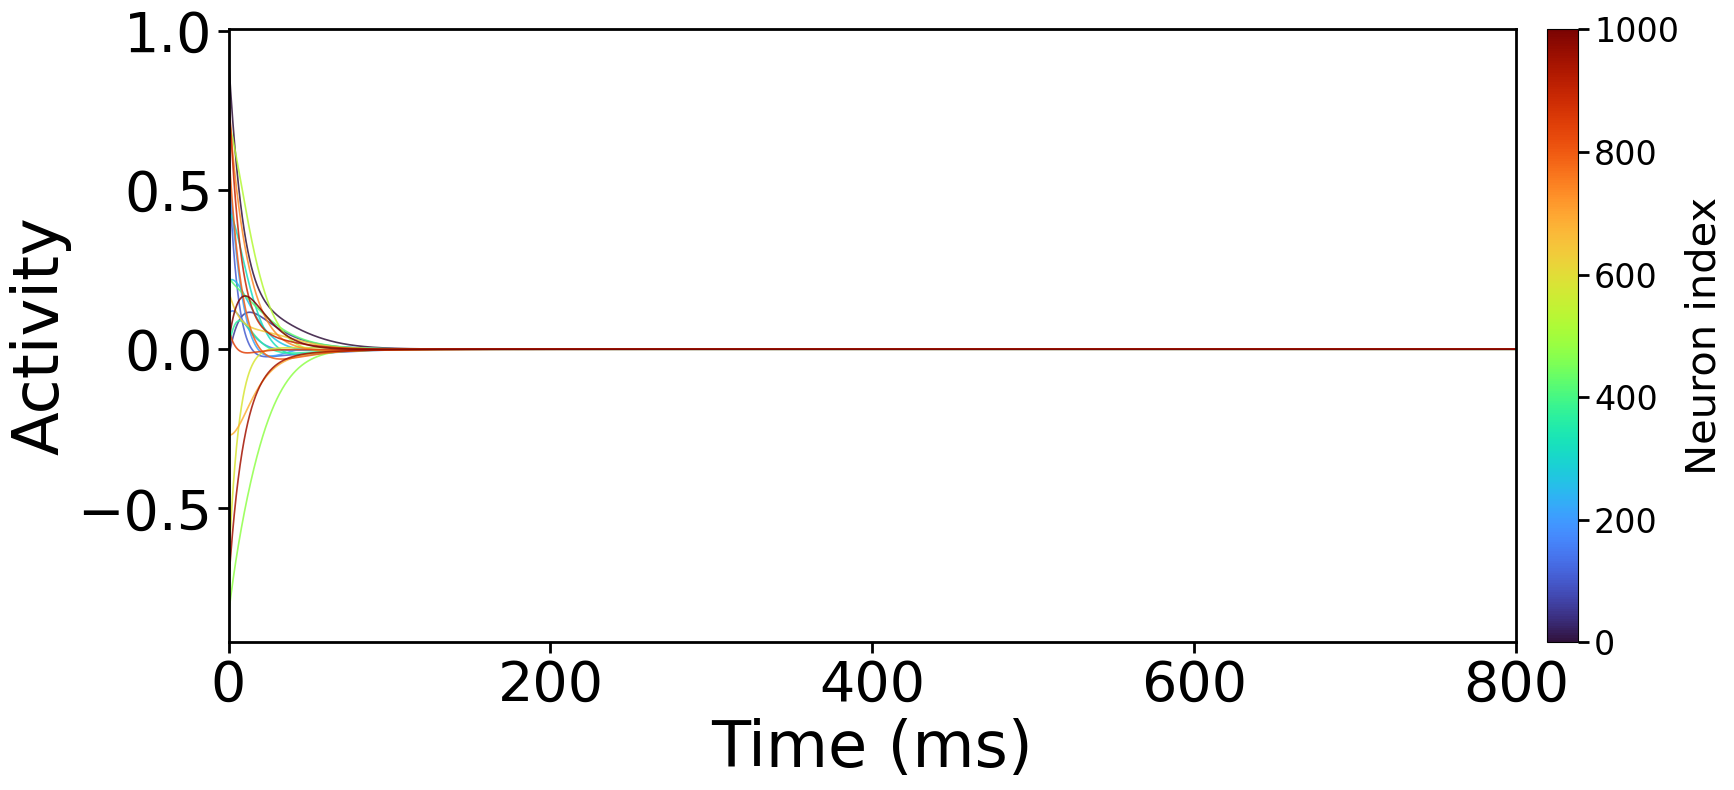

  Saved → p=0.2 without self connections gain 1.5, MSH 1.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


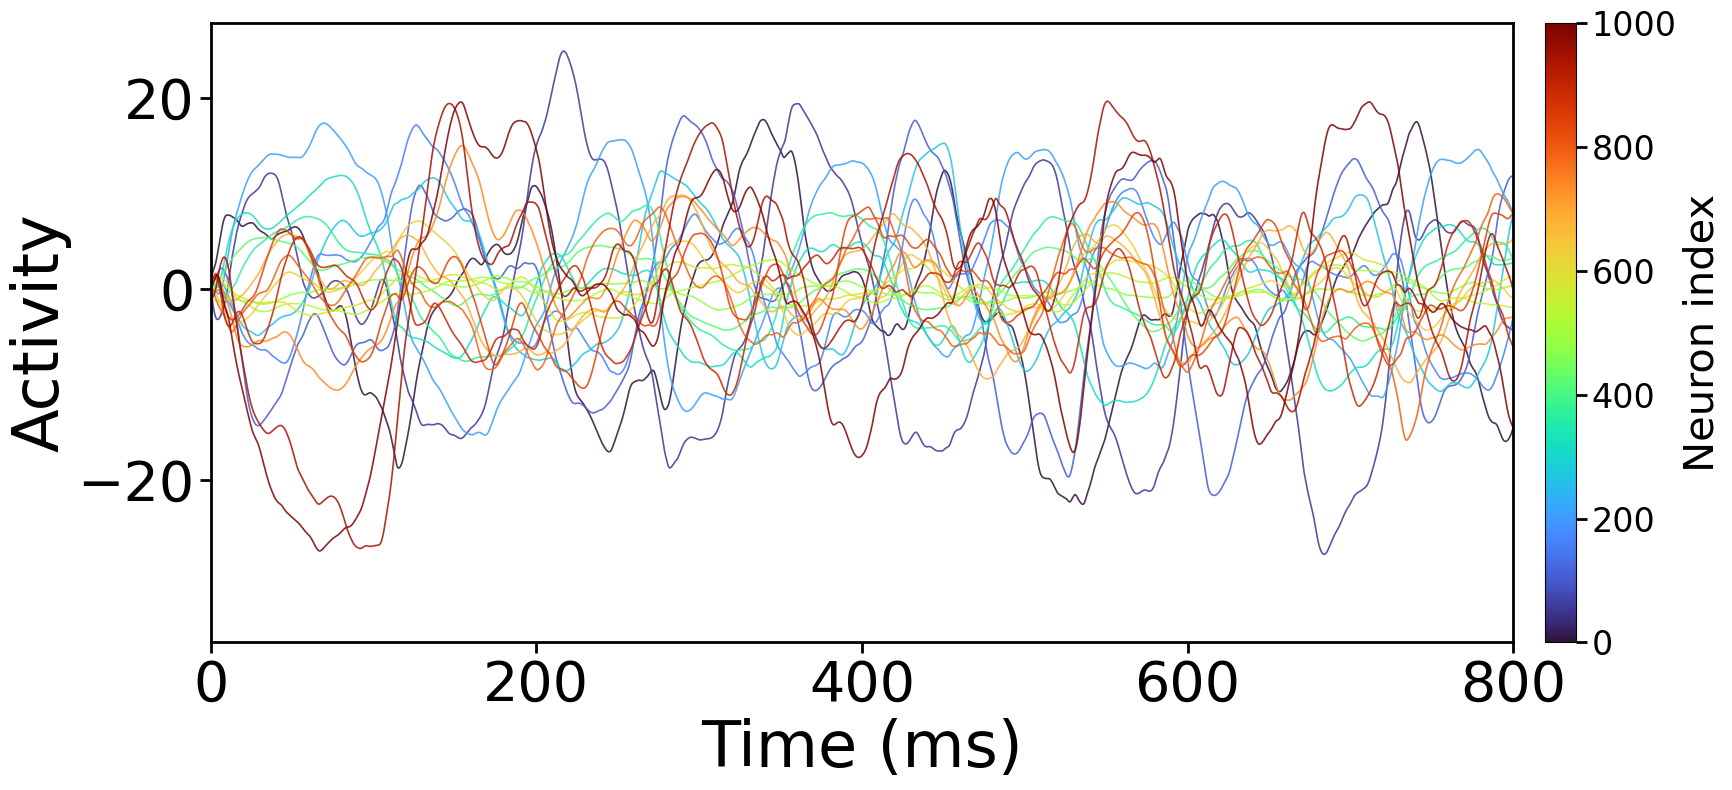

  Saved → p=0.2 without self connections gain 6.0, MSH 5.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


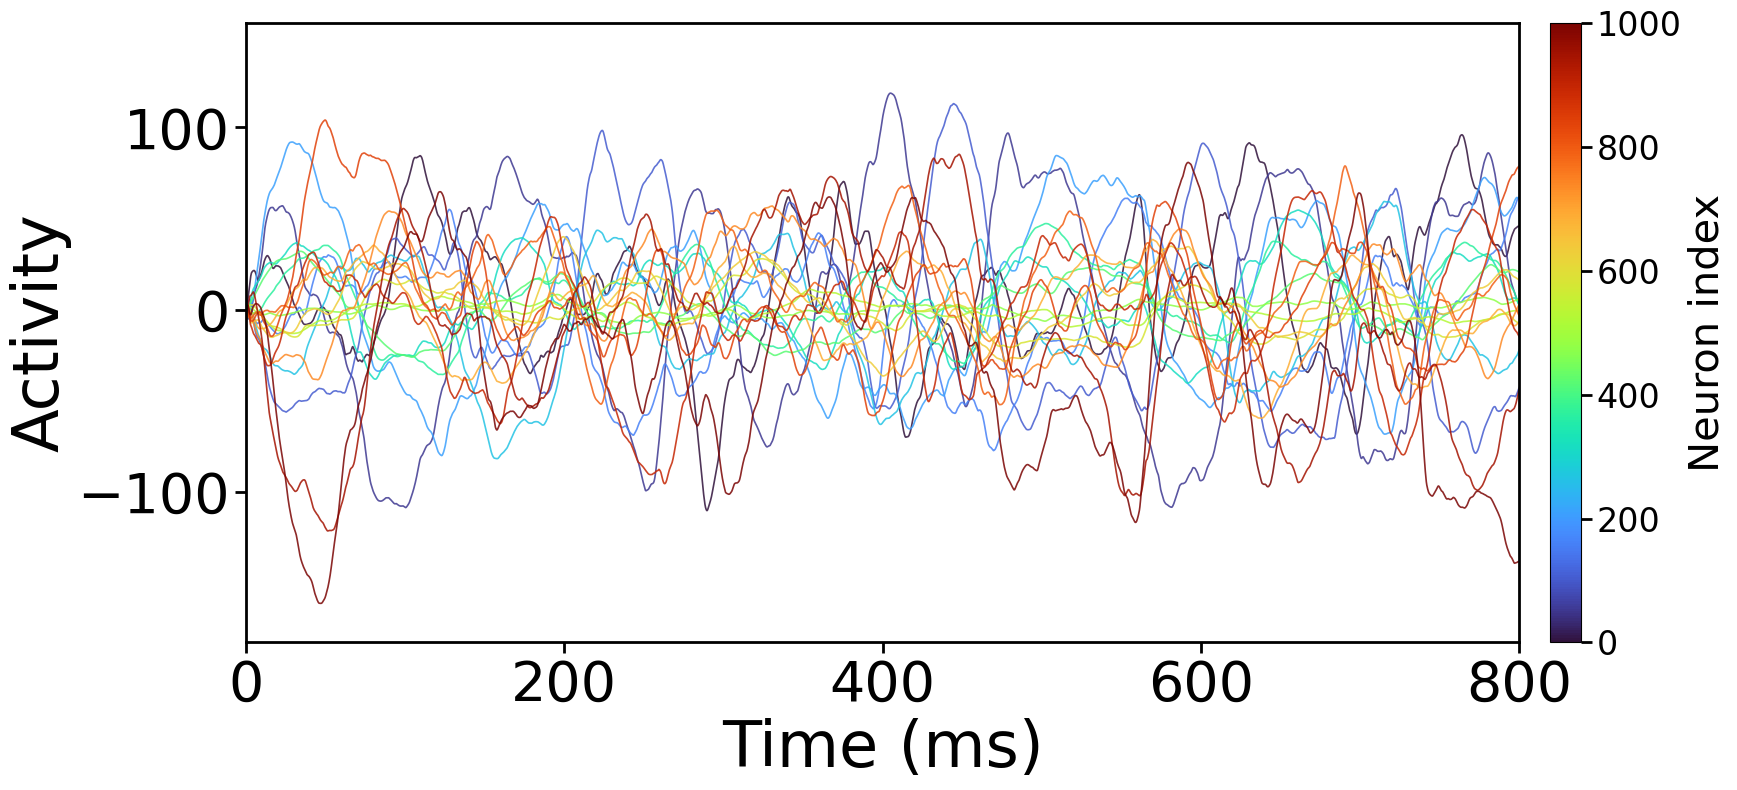

  Saved → p=1.0 with self connections gain 0.5, MSH 0.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


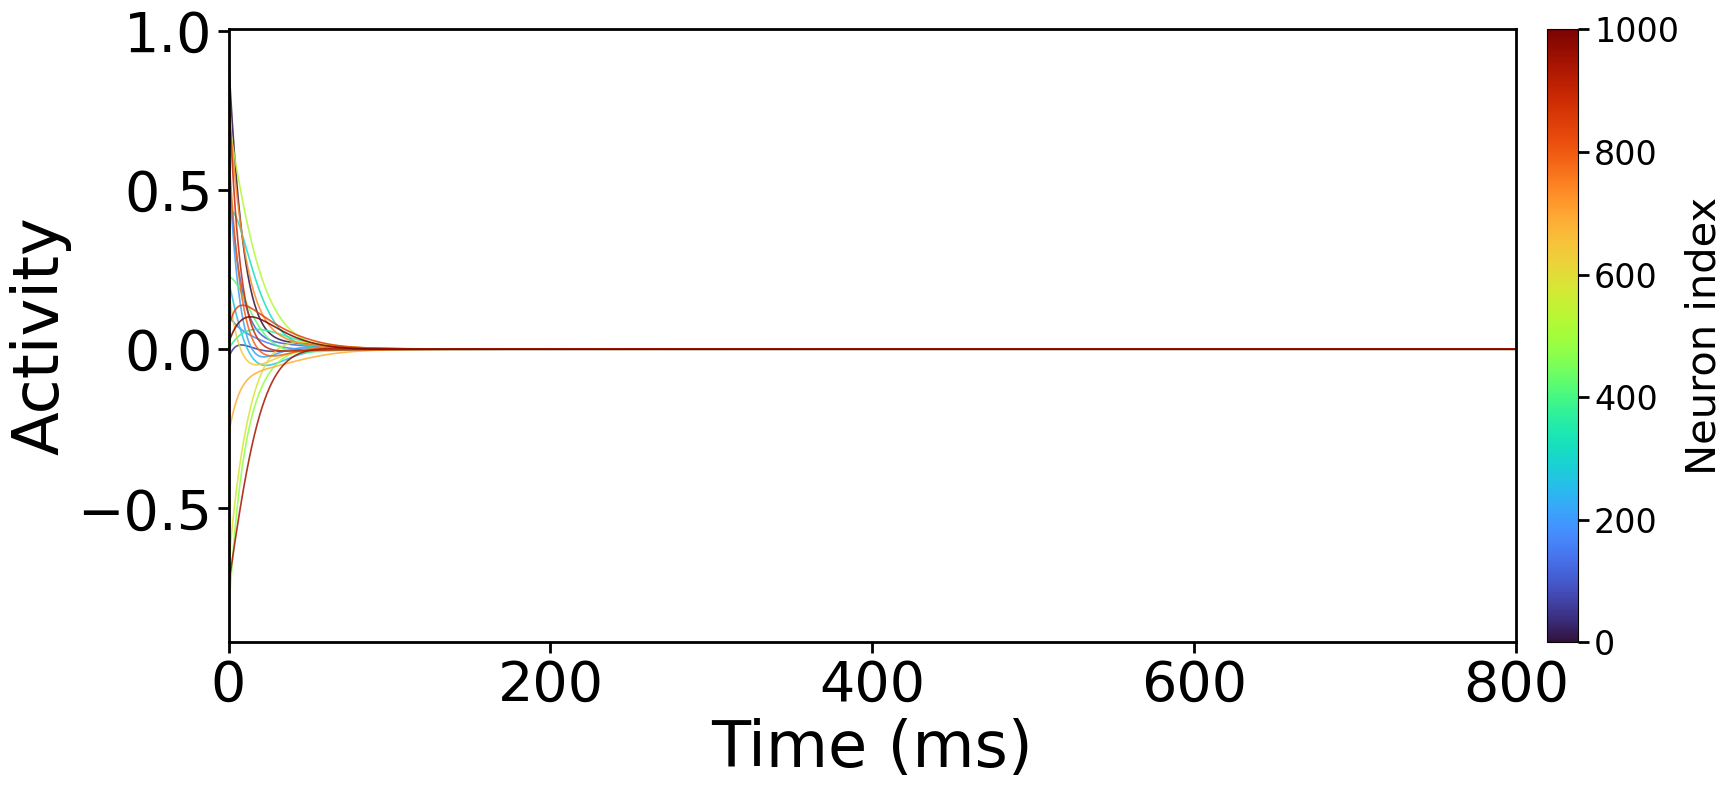

  Saved → p=1.0 with self connections gain 1.5, MSH 1.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


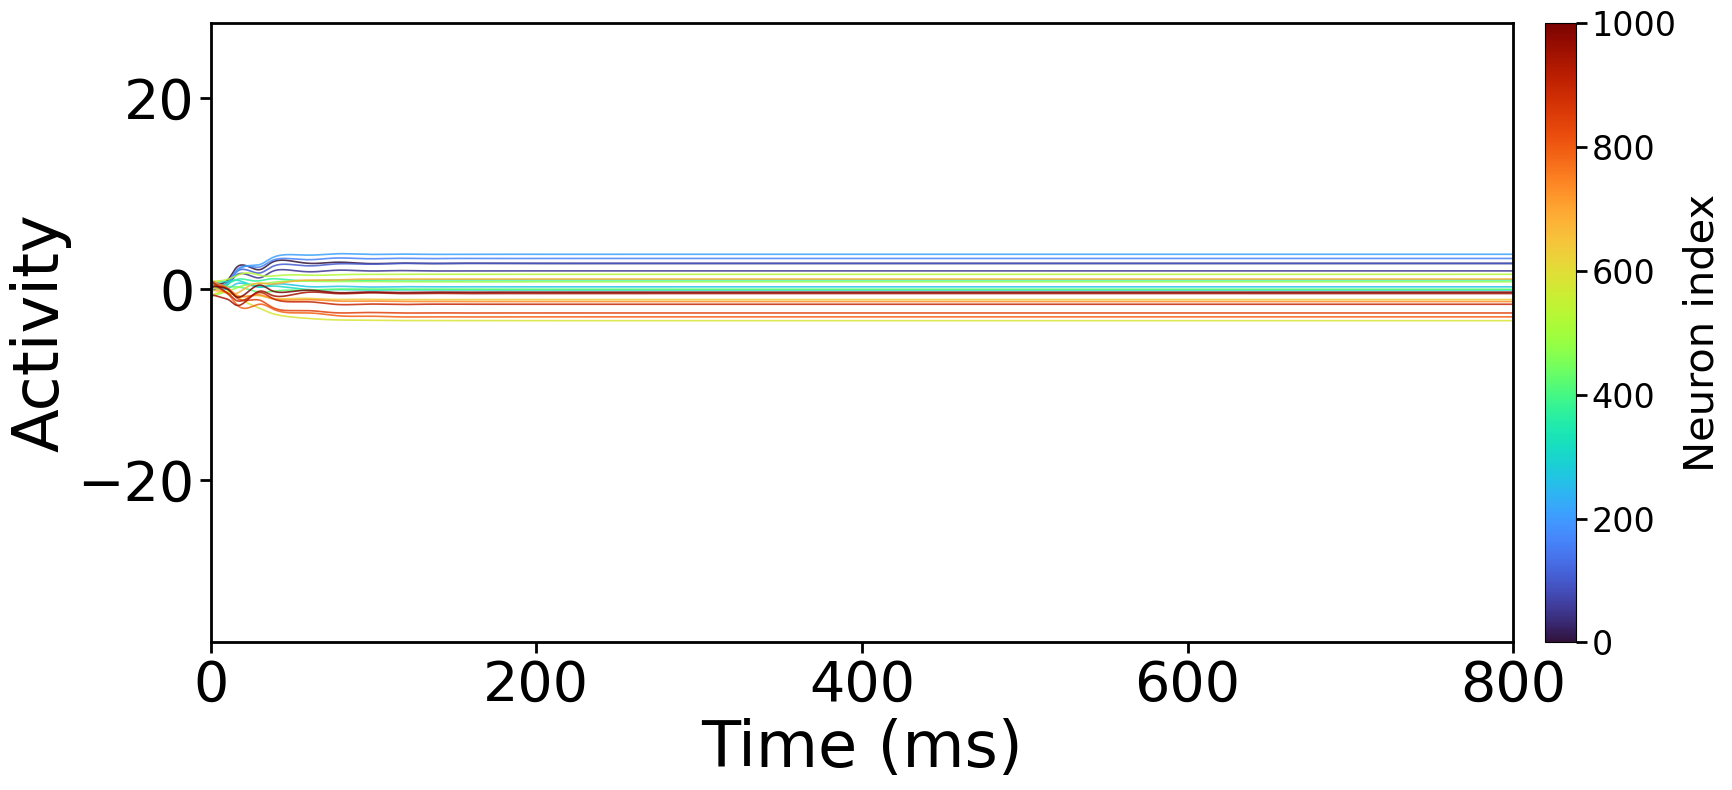

  Saved → p=1.0 with self connections gain 6.0, MSH 5.0, W seed 9, and I seed 0 time20260517_152616, Neurons=first and last and middle.png


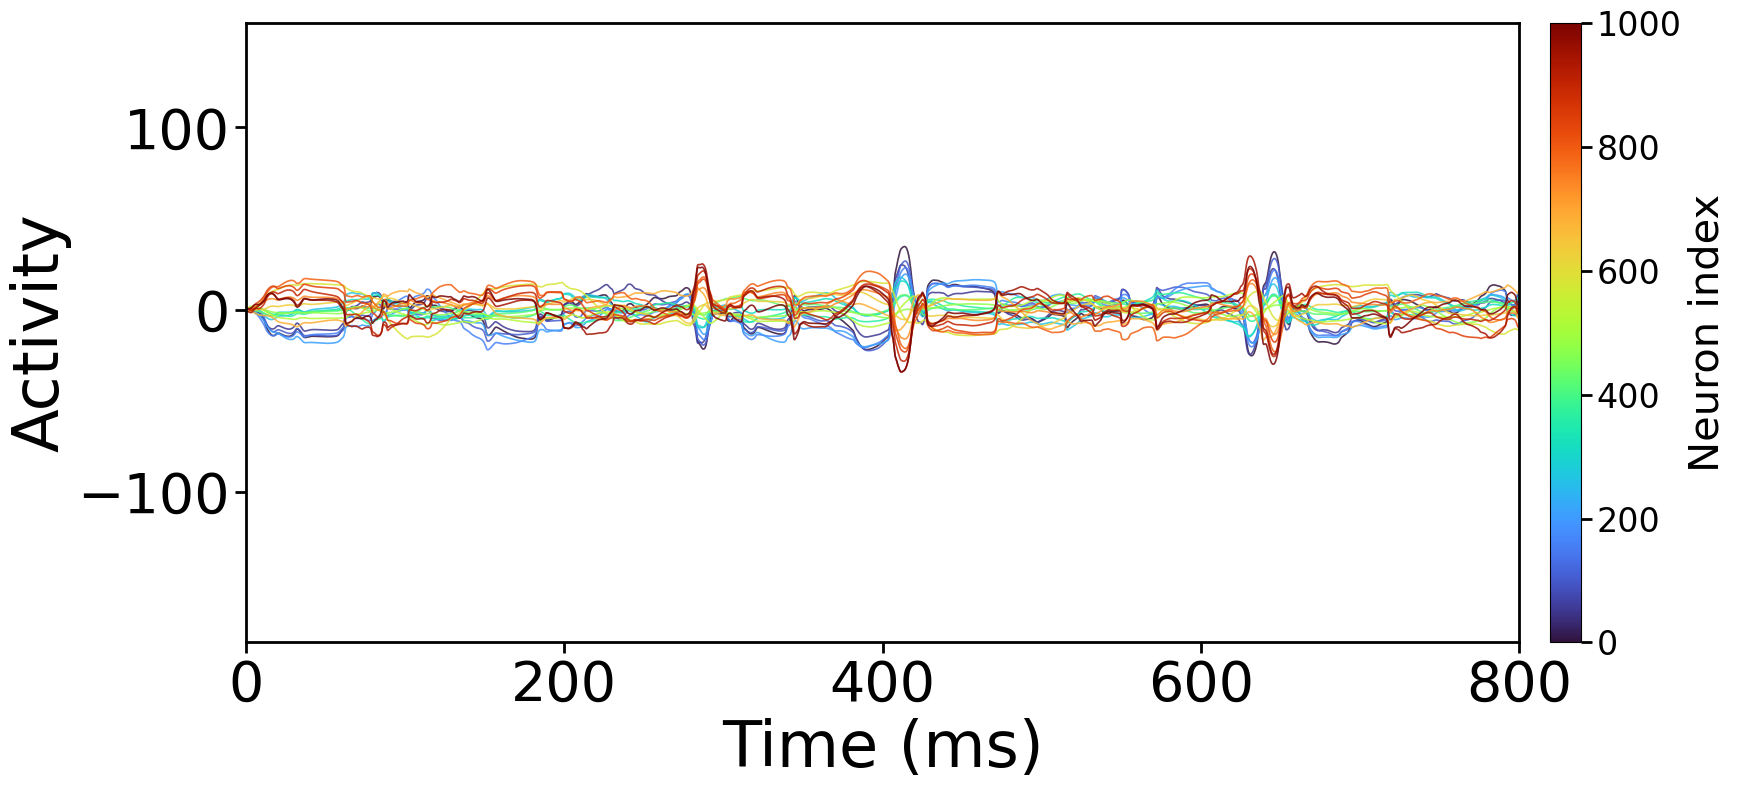

All done.


In [81]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import datetime
import os

# ── rcParams ──────────────────────────────────────────────────────────────────
plt.rcParams['axes.titlesize']        = 30
plt.rcParams['axes.labelsize']        = 46
plt.rcParams['xtick.labelsize']       = 40
plt.rcParams['ytick.labelsize']       = 40
plt.rcParams['legend.fontsize']       = 36
plt.rcParams['figure.titlesize']      = 30
plt.rcParams['legend.title_fontsize'] = 30
plt.rcParams['xtick.major.size']      = 8
plt.rcParams['ytick.major.size']      = 8
plt.rcParams['xtick.major.width']     = 2
plt.rcParams['ytick.major.width']     = 2

# ── Network dynamics ──────────────────────────────────────────────────────────
def rate_network(x, W, I, tau):
    """dx/dt = (-x + W @ phi(x) + I) / tau"""
    phi = np.tanh(x)
    return (-x + W @ phi + I) / tau

def euler_rate_network(W, tau, dt, t_steps, x0, I, return_full=True):
    N = len(x0)
    if return_full:
        x    = np.zeros((t_steps, N), dtype=x0.dtype)
        x[0] = x0
    X = np.copy(x0)
    for i in range(1, t_steps):
        Ii = I[i - 1] if I.ndim == 2 else I
        X  = X + dt * rate_network(X, W, Ii, tau)
        if return_full:
            x[i] = X
    return x if return_full else X

def weight_matrix_fast(p, N, HSM, gain, rng_weights):
    mus = np.linspace(-HSM, HSM, N)
    W = rng_weights.normal(
        loc=mus[:, None],
        scale=gain / np.sqrt(p * N),
        size=(N, N)
    )
    mask = rng_weights.random(W.shape) < p
    W *= mask
    #np.fill_diagonal(W, 0)
    return W

# ── Fixed parameters ──────────────────────────────────────────────────────────
N             = 1000
tau           = 10
dt            = 0.1
running_time  = np.arange(0, 800 + dt, dt)
t_steps       = len(running_time)
n_weight_seed = 9
n_init_seed   = 0

save_dir = r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\Activity RNN\supplementary figures for self connection and sparse activity THESIS"

# ── Loop conditions ───────────────────────────────────────────────────────────
# (p, self_connections)
connectivity_conditions = [
    (0.2, True),
    (0.2, False),
    (1.0, True),
]

# (gain, HSM)
gain_HSM_combinations = [
    (0.5, 0.0),
    (1.5, 1.0),
    (6.0, 5.0),
]

# ── Neuron indices and turbo colours ─────────────────────────────────────────
n_plot  = 20
indices = np.linspace(0, N - 1, n_plot, dtype=int)
colors  = cm.turbo(np.linspace(0, 1, n_plot))

# ── Pass 1: run all simulations to find per-(gain,HSM) y-limits ──────────────
print("Pass 1: simulating all conditions...")
all_activities = {}
# y-limits stored per (gain, HSM) combination
ylims = {(gain, HSM): [np.inf, -np.inf] for gain, HSM in gain_HSM_combinations}

for p, self_conn in connectivity_conditions:
    for gain, HSM in gain_HSM_combinations:

        weights_seq        = np.random.SeedSequence(entropy=654321,
                                                     spawn_key=(0, n_weight_seed))
        initialisation_seq = np.random.SeedSequence(entropy=654321,
                                                     spawn_key=(0, n_weight_seed,
                                                                n_init_seed))
        rng_weights = np.random.default_rng(weights_seq)
        rng_init    = np.random.default_rng(initialisation_seq)

        x0 = rng_init.uniform(-1.0, 1.0, size=N)
        W  = weight_matrix_fast(p, N, HSM, gain, rng_weights)
        if not self_conn:
            np.fill_diagonal(W, 0)

        I        = np.zeros((t_steps, N))
        activity = euler_rate_network(W, tau, dt, t_steps, x0, I, return_full=True)

        # store only the plotted neurons
        key = (p, self_conn, gain, HSM)
        all_activities[key] = activity[:, indices]

        ylims[(gain, HSM)][0] = min(ylims[(gain, HSM)][0], activity[:, indices].min())
        ylims[(gain, HSM)][1] = max(ylims[(gain, HSM)][1], activity[:, indices].max())

# add 5% margin per group
for gm_key in ylims:
    ymin, ymax = ylims[gm_key]
    margin = 0.05 * (ymax - ymin)
    ylims[gm_key] = [ymin - margin, ymax + margin]
    print(f"  gain={gm_key[0]:.1f}, HSM={gm_key[1]:.1f}  →  y-limits: [{ylims[gm_key][0]:.4f}, {ylims[gm_key][1]:.4f}]")

# ── Pass 2: plot and save ─────────────────────────────────────────────────────
print("Pass 2: plotting and saving...")
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

for p, self_conn in connectivity_conditions:
    conn_str  = "with self connections" if self_conn else "without self connections"

    for gain, HSM in gain_HSM_combinations:
        key      = (p, self_conn, gain, HSM)
        act_plot = all_activities[key]          # shape (t_steps, n_plot)

        fig, ax = plt.subplots(figsize=(18, 8))

        for k in range(n_plot):
            ax.plot(running_time, act_plot[:, k],
                    lw=1.2, alpha=0.85, color=colors[k])

        # x axis same for all; y axis same within each gain/HSM group
        ax.set_xlim(running_time[0], running_time[-1])
        ax.set_ylim(ylims[(gain, HSM)][0], ylims[(gain, HSM)][1])

        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Activity')
        # no title

        for spine in ax.spines.values():
            spine.set_linewidth(2)

        # colourbar: vmax=N so tick at 1000 is included
        sm = cm.ScalarMappable(cmap='turbo',
                               norm=plt.Normalize(vmin=0, vmax=N))
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label('Neuron index', fontsize=30)
        cbar.set_ticks([0, 200, 400, 600, 800, 1000])
        cbar.set_ticklabels(['0', '200', '400', '600', '800', '1000'])
        cbar.ax.tick_params(labelsize=24)

        plt.tight_layout()

        filename = (
            f"p={p:.1f} {conn_str} gain {gain:.1f}, HSM {HSM:.1f}, "
            f"W seed {n_weight_seed}, and I seed {n_init_seed} "
            f"time{timestamp}, Neurons=first and last and middle.png"
        )
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        print(f"  Saved → {filename}")

        plt.show()

print("All done.")


# Plotting the Distributions of Weights

In [ ]:
# Build a weight matrix for every (gain, weights_seed, HSM) combination and
# keep them all in memory (Ws) -- used by the distribution plots in the next cell.
# Parameters
N = 1000
tau = 10
dt = 0.1
p = 1

running_time = np.arange(0, 3000 + dt, dt)
interval = 200
reset_steps = int(interval / dt)
perturbation = 1e-8

n_weight_seeds = 1
HSMs = np.arange(0, 10, 1)
gains = np.arange(0, 10, 1)
# HSMs = np.array([100])
# HSMs = np.arange(0, 1.2, 0.2)
# gains = np.arange(0, 1.2, 0.2)

tasks = list(product(gains, range(n_weight_seeds), HSMs))

Ws = []
local_Weights_Seeds = []
local_HSMs = []
local_Gains = []

for gain, weights_seed, HSM in tasks:

    weights_seq = np.random.SeedSequence(entropy=654321, spawn_key=(0, weights_seed))
    rng_weights = np.random.default_rng(weights_seq)

    W = md.compute_weight_matrix(p, N, HSM, gain, rng_weights)
    Ws.append(W)

    # Track parameters alongside results for later identification
    local_Gains.append(gain)
    local_Weights_Seeds.append(weights_seed)
    local_HSMs.append(HSM)

local_Weights_Seeds = np.array(local_Weights_Seeds)
local_HSMs = np.array(local_HSMs)
local_Gains = np.array(local_Gains)
Ws = np.array(Ws)


In [ ]:
# Weight distribution histograms for a few (gain, HSM) combinations.
#
# NOTE: `p`, `N`, and `rng_weights` are not (re)defined in this cell -- it
# relies on them still being HSM from running the previous cell (cell 26)
# first, where p=1, N=1000, and rng_weights ends up holding whatever RNG
# stream was last created there (weights_seed from the final task in that
# cell's loop). Run cell 26 before this one, or define these explicitly
# here if you want this cell to be independent.
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 26    # x/y labels
plt.rcParams['xtick.labelsize'] = 14   # x ticks
plt.rcParams['ytick.labelsize'] = 14   # y ticks
plt.rcParams['legend.fontsize'] = 12   # legend text
plt.rcParams['figure.titlesize'] = 22  # suptitle (global title)
plt.rcParams['legend.title_fontsize'] = 18  # legend title

HSMs = np.array([0, 2.5, 5])
gains = np.array([0, 5, 10])

for g in gains:
    for HSM in HSMs:
        W = md.compute_weight_matrix(p, N, HSM, g, rng_weights)

        plt.hist(W.ravel(), bins=1000, alpha=1, color="tab:green", edgecolor="tab:green",
                 label=f"W_M_F HSM:{HSM}, g:{g}")
        plt.ylabel('Frequency')
        plt.xlabel('Values of $\\mathregular{J_{ij}}$')
        plt.title(f"Total distribution of J for gain = {g} and HSM = {HSM}", pad=20)
        plt.xlim([-6.0, 6.0])

        # Only set ylim if BOTH gain and HSM are NOT zero
        if not (g == 0 and HSM == 0):
            plt.ylim([0, 5200])

        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"gain{g:.1f}_HSM{HSM:.1f}_time{timestamp}.png"
        # NOTE: hardcoded, machine-specific path
        filepath = os.path.join(
            r"C:\Users\Lenovo\Documents\B. Master Neurophysics\Stage\Presentations and reports and code\code\Activity RNN\Distributions different HSM and gain",
            filename
        )
        plt.savefig(filepath, dpi=300, bbox_inches='tight')
        plt.show()
